In [211]:
!pip install -q kagglehub

import os
import re
import glob
import csv
import time
from dataclasses import dataclass
from typing import List
!pip install -q kagglehub
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [212]:
import kagglehub
import os

# Download latest version of the Waveform Inversion competition
path = kagglehub.competition_download("waveform-inversion")

print("Path to competition files:")
print(path)

print("\nFiles/folders:")
for item in os.listdir(path):
    print(" -", item)

Path to competition files:
/kaggle/input/competitions/waveform-inversion

Files/folders:
 - sample_submission.csv
 - train_samples
 - test


In [213]:
import os

# Search recursively for the important folders
train_root = None
test_dir = None
sample_submission = None

for root, dirs, files in os.walk(path):

    # Training directory
    if os.path.basename(root) == "train_samples":
        train_root = root

    # Test directory
    if os.path.basename(root) == "test":
        test_dir = root

    # Sample submission
    for file in files:
        if file == "sample_submission.csv":
            sample_submission = os.path.join(root, file)

print("TRAIN ROOT:")
print(train_root)

print("\nTEST DIR:")
print(test_dir)

print("\nSAMPLE SUBMISSION:")
print(sample_submission)

TRAIN ROOT:
/kaggle/input/competitions/waveform-inversion/train_samples

TEST DIR:
/kaggle/input/competitions/waveform-inversion/test

SAMPLE SUBMISSION:
/kaggle/input/competitions/waveform-inversion/sample_submission.csv


In [214]:
assert train_root is not None, "train_samples directory not found!"
assert test_dir is not None, "test directory not found!"
assert sample_submission is not None, "sample_submission.csv not found!"

print("✓ Dataset successfully located")
print()
print("Train:", train_root)
print("Test:", test_dir)
print("Submission:", sample_submission)

✓ Dataset successfully located

Train: /kaggle/input/competitions/waveform-inversion/train_samples
Test: /kaggle/input/competitions/waveform-inversion/test
Submission: /kaggle/input/competitions/waveform-inversion/sample_submission.csv


In [215]:
TRAIN_ROOT = train_root
TEST_DIR = test_dir
SAMPLE_SUBMISSION = sample_submission

print("TRAIN_ROOT =", TRAIN_ROOT)
print("TEST_DIR =", TEST_DIR)
print("SAMPLE_SUBMISSION =", SAMPLE_SUBMISSION)

TRAIN_ROOT = /kaggle/input/competitions/waveform-inversion/train_samples
TEST_DIR = /kaggle/input/competitions/waveform-inversion/test
SAMPLE_SUBMISSION = /kaggle/input/competitions/waveform-inversion/sample_submission.csv


In [216]:
@dataclass
class FilePair:
    seis_path: str
    vel_path: str
    family: str

In [217]:
VELSTYLE_DATA_RE = re.compile(r"^data(\d+)\.npy$")
FAULT_SEIS_RE = re.compile(r"^seis_(\d+)_1_(\d+)\.npy$")


def _infer_family(path: str) -> str:
    p = path.lower()

    if "fault" in p:
        return "fault"

    if "style" in p:
        return "style"

    if "vel" in p:
        return "vel"

    return "unknown"

In [218]:
def discover_pairs(root_dir: str) -> List[FilePair]:

    pairs = []

    # ==========================================
    # Vel / Style
    # ==========================================

    for data_dir in glob.glob(
        os.path.join(root_dir, "**", "data"),
        recursive=True
    ):

        parent = os.path.dirname(data_dir)
        model_dir = os.path.join(parent, "model")

        if not os.path.isdir(model_dir):
            continue

        family = _infer_family(parent)

        for data_file in sorted(
            glob.glob(os.path.join(data_dir, "data*.npy"))
        ):

            m = VELSTYLE_DATA_RE.match(
                os.path.basename(data_file)
            )

            if not m:
                continue

            model_file = os.path.join(
                model_dir,
                f"model{m.group(1)}.npy"
            )

            if os.path.exists(model_file):

                pairs.append(
                    FilePair(
                        data_file,
                        model_file,
                        family
                    )
                )

    # ==========================================
    # Fault
    # ==========================================

    for seis_file in glob.glob(
        os.path.join(
            root_dir,
            "**",
            "seis_*_1_*.npy"
        ),
        recursive=True
    ):

        m = FAULT_SEIS_RE.match(
            os.path.basename(seis_file)
        )

        if not m:
            continue

        n, i = m.group(1), m.group(2)

        vel_file = os.path.join(
            os.path.dirname(seis_file),
            f"vel_{n}_1_{i}.npy"
        )

        if os.path.exists(vel_file):

            pairs.append(
                FilePair(
                    seis_file,
                    vel_file,
                    "fault"
                )
            )

    return pairs

In [219]:
pairs = discover_pairs(TRAIN_ROOT)

print(f"Found {len(pairs)} file pairs.")

family_counts = {}

for p in pairs:
    family_counts[p.family] = family_counts.get(p.family, 0) + 1

print("\nFamilies:")

for family, count in family_counts.items():
    print(f"{family}: {count}")

Found 12 file pairs.

Families:
vel: 8
style: 4


In [220]:
for p in pairs[:10]:

    print("Family:", p.family)
    print("Seismic:", p.seis_path)
    print("Velocity:", p.vel_path)

    seis = np.load(p.seis_path, mmap_mode="r")
    vel = np.load(p.vel_path, mmap_mode="r")

    print("Seismic shape:", seis.shape)
    print("Velocity shape:", vel.shape)
    print("-" * 80)

Family: vel
Seismic: /kaggle/input/competitions/waveform-inversion/train_samples/FlatVel_A/data/data1.npy
Velocity: /kaggle/input/competitions/waveform-inversion/train_samples/FlatVel_A/model/model1.npy
Seismic shape: (500, 5, 1000, 70)
Velocity shape: (500, 1, 70, 70)
--------------------------------------------------------------------------------
Family: vel
Seismic: /kaggle/input/competitions/waveform-inversion/train_samples/FlatVel_A/data/data2.npy
Velocity: /kaggle/input/competitions/waveform-inversion/train_samples/FlatVel_A/model/model2.npy
Seismic shape: (500, 5, 1000, 70)
Velocity shape: (500, 1, 70, 70)
--------------------------------------------------------------------------------
Family: vel
Seismic: /kaggle/input/competitions/waveform-inversion/train_samples/CurveVel_A/data/data1.npy
Velocity: /kaggle/input/competitions/waveform-inversion/train_samples/CurveVel_A/model/model1.npy
Seismic shape: (500, 5, 1000, 70)
Velocity shape: (500, 1, 70, 70)
--------------------------

****NORMALIZATION****

In [221]:
def compute_seis_scale(
    pairs,
    n_files=5,
    n_samples=20,
    percentile=99.0,
    seed=0
):

    rng = np.random.default_rng(seed)

    vals = []

    for pair in pairs[:n_files]:

        arr = np.load(
            pair.seis_path,
            mmap_mode="r"
        )

        idxs = rng.choice(
            arr.shape[0],
            size=min(n_samples, arr.shape[0]),
            replace=False
        )

        for i in idxs:

            vals.append(
                np.abs(
                    np.asarray(arr[i])
                ).ravel()
            )

    if not vals:
        return 1.0

    scale = float(
        np.percentile(
            np.concatenate(vals),
            percentile
        )
    )

    return scale if scale > 1e-6 else 1.0

In [222]:
SEED = 42
VAL_FRAC = 0.10

In [223]:
seis_scale = compute_seis_scale(
    pairs,
    seed=SEED
)

print("Seismic scale:", seis_scale)

Seismic scale: 6.3900651931762695


In [224]:
def family_stratified_split(
    pairs,
    val_frac=0.1,
    seed=0
):

    rng = np.random.default_rng(seed)

    by_family = {}

    for p in pairs:

        by_family.setdefault(
            p.family,
            []
        ).append(p)

    train = []
    val = []

    for family, fam_pairs in by_family.items():

        fam_pairs = list(fam_pairs)

        rng.shuffle(fam_pairs)

        n_val = (
            max(
                1,
                int(round(len(fam_pairs) * val_frac))
            )
            if len(fam_pairs) > 1
            else 0
        )

        val.extend(
            fam_pairs[:n_val]
        )

        train.extend(
            fam_pairs[n_val:]
        )

    return train, val

In [225]:
train_pairs, val_pairs = family_stratified_split(
    pairs,
    val_frac=VAL_FRAC,
    seed=SEED
)

print("Training files:", len(train_pairs))
print("Validation files:", len(val_pairs))

print("\nTraining families:")

for p in train_pairs:
    pass

train_counts = {}

for p in train_pairs:
    train_counts[p.family] = train_counts.get(p.family, 0) + 1

print(train_counts)

print("\nValidation families:")

val_counts = {}

for p in val_pairs:
    val_counts[p.family] = val_counts.get(p.family, 0) + 1

print(val_counts)

Training files: 10
Validation files: 2

Training families:
{'vel': 7, 'style': 3}

Validation families:
{'vel': 1, 'style': 1}


In [226]:
class FWIDataset(Dataset):

    def __init__(
        self,
        pairs,
        seis_scale,
        vel_min=1500.0,
        vel_max=4500.0
    ):

        self.pairs = pairs
        self.seis_scale = seis_scale

        self.vel_min = vel_min
        self.vel_max = vel_max

        self._mmap_cache = {}

        self._index = []

        for pi, pair in enumerate(pairs):

            arr = self._get_mmap(
                pair.seis_path
            )

            for li in range(arr.shape[0]):

                self._index.append(
                    (pi, li)
                )

    def _get_mmap(self, path):

        arr = self._mmap_cache.get(path)

        if arr is None:

            arr = np.load(
                path,
                mmap_mode="r"
            )

            self._mmap_cache[path] = arr

        return arr

    def __len__(self):

        return len(self._index)

    def __getitem__(self, idx):

        pi, li = self._index[idx]

        pair = self.pairs[pi]

        seis = np.asarray(
            self._get_mmap(
                pair.seis_path
            )[li],
            dtype=np.float32
        )

        vel = np.asarray(
            self._get_mmap(
                pair.vel_path
            )[li],
            dtype=np.float32
        )

        # Seismic normalization
        seis = seis / self.seis_scale

        # Velocity normalization [-1,1]
        vel = (
            (vel - self.vel_min)
            / (self.vel_max - self.vel_min)
            * 2.0
            - 1.0
        )

        seis_t = torch.from_numpy(seis)

        vel_t = torch.from_numpy(
            vel
        ).unsqueeze(0)

        return seis_t, vel_t

In [227]:
# ==========================================
# CONFIG / HYPERPARAMETERS
# (was missing entirely - caused NameError everywhere below)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
NUM_WORKERS = 2

LR = 3e-4
EPOCHS = 100

VEL_MIN = 1500.0
VEL_MAX = 4500.0

USE_AMP = True

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device:", device)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)
print("Velocity range:", VEL_MIN, "-", VEL_MAX, "m/s")
print("Checkpoint dir:", CHECKPOINT_DIR)


Device: cuda
Batch size: 32
Learning rate: 0.0003
Velocity range: 1500.0 - 4500.0 m/s
Checkpoint dir: checkpoints


In [228]:
train_ds = FWIDataset(
    train_pairs,
    seis_scale,
    VEL_MIN,
    VEL_MAX
)

val_ds = FWIDataset(
    val_pairs,
    seis_scale,
    VEL_MIN,
    VEL_MAX
)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))

Train samples: 5000
Validation samples: 1000


In [229]:
sample_seis, sample_vel = train_ds[0]

print("Seismic shape:", sample_seis.shape)
print("Velocity shape:", sample_vel.shape)

print("\nSeismic:")
print("min:", sample_seis.min().item())
print("max:", sample_seis.max().item())

print("\nVelocity normalized:")
print("min:", sample_vel.min().item())
print("max:", sample_vel.max().item())

Seismic shape: torch.Size([5, 1000, 70])
Velocity shape: torch.Size([1, 1, 70, 70])

Seismic:
min: -4.156911373138428
max: 8.122482299804688

Velocity normalized:
min: 0.6419999599456787
max: 0.8566666841506958


Original velocity shape: torch.Size([1, 1, 70, 70])
After squeeze: (70, 70)
Final velocity shape: (70, 70)


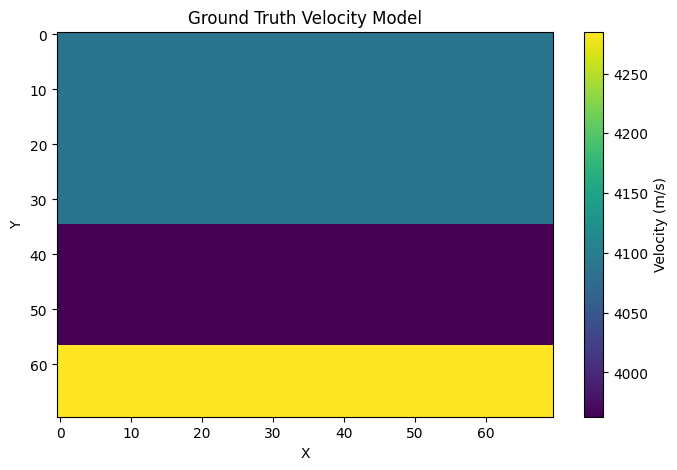

In [230]:
# Get one sample
sample_seis, sample_vel = train_ds[0]

print("Original velocity shape:", sample_vel.shape)

# Convert tensor -> numpy
vel_np = sample_vel.detach().cpu().numpy()

# FORCE the velocity map to H x W
vel_np = np.squeeze(vel_np)

print("After squeeze:", vel_np.shape)

# Safety check
assert vel_np.ndim == 2, f"Expected 2D velocity map, got {vel_np.shape}"

# Convert normalized [-1, 1] -> real velocity (m/s)
vel_real = (
    (vel_np + 1.0)
    / 2.0
    * (VEL_MAX - VEL_MIN)
    + VEL_MIN
)

print("Final velocity shape:", vel_real.shape)

# Plot
plt.figure(figsize=(8, 5))

plt.imshow(
    vel_real,
    aspect="auto"
)

plt.colorbar(
    label="Velocity (m/s)"
)

plt.title("Ground Truth Velocity Model")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

Seismic shape: (5, 1000, 70)


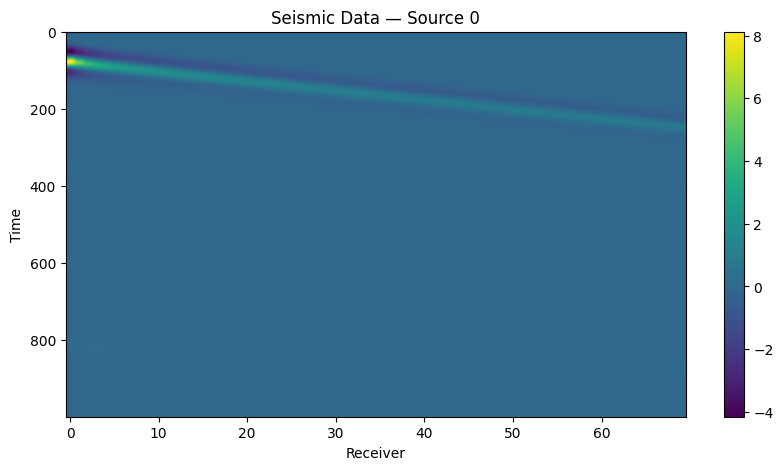

In [231]:
seis_np = sample_seis.numpy()

print("Seismic shape:", seis_np.shape)
plt.figure(figsize=(10, 5))

plt.imshow(
    seis_np[0],
    aspect="auto"
)

plt.colorbar()
plt.title("Seismic Data — Source 0")
plt.xlabel("Receiver")
plt.ylabel("Time")

plt.show()

**MODEL**

In [232]:
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch,
        stride=2
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                stride=stride,
                padding=1
            ),

            nn.BatchNorm2d(out_ch),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.BatchNorm2d(out_ch),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

In [233]:
class DeconvBlock(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.ConvTranspose2d(
                in_ch,
                out_ch,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(out_ch),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

expirment 2

In [ ]:
class InversionNet(nn.Module):
    """
    Restored: this is the architecture your earlier successful run
    actually used (reconstructed from the saved model printout /
    parameter counts). ConvBlock encoder/bottleneck/decoder stages
    with bilinear upsampling + skip connections (DeconvBlock above
    is defined but not used by this architecture).
    """

    def __init__(self, in_channels, base_channels=32, out_hw=(70, 70)):
        super().__init__()

        self.out_hw = tuple(out_hw)

        c1 = base_channels       # 32
        c2 = base_channels * 2   # 64
        c3 = base_channels * 4   # 128
        c4 = base_channels * 8   # 256

        # Encoder
        self.enc1 = ConvBlock(in_channels, c1, stride=2)
        self.enc2 = ConvBlock(c1, c2, stride=2)
        self.enc3 = ConvBlock(c2, c3, stride=2)
        self.enc4 = ConvBlock(c3, c4, stride=2)

        # Bottleneck
        self.bottleneck = ConvBlock(c4, c4, stride=1)

        # Decoder (upsample via interpolate, concat skip, then ConvBlock)
        self.dec4 = ConvBlock(c4 + c4, c3, stride=1)
        self.dec3 = ConvBlock(c3 + c3, c2, stride=1)
        self.dec2 = ConvBlock(c2 + c2, c1, stride=1)
        self.dec1 = ConvBlock(c1 + c1, c1, stride=1)

        self.out_conv = nn.Conv2d(c1, 1, kernel_size=3, padding=1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        b = self.bottleneck(e4)

        d4 = F.interpolate(b, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = F.interpolate(d4, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = F.interpolate(d3, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = F.interpolate(d2, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        out = F.interpolate(out, size=self.out_hw, mode="bilinear", align_corners=False)

        # Velocity is normalized to [-1, 1]
        return torch.tanh(out)


print("InversionNet restored and loaded.")


In [235]:
# # ============================================================
# # EXPERIMENT 2 — 5-DEPTH RESIDUAL U-NET
# # ============================================================

# import torch
# import torch.nn as nn
# import torch.nn.functional as F


# # ------------------------------------------------------------
# # Residual Block
# # ------------------------------------------------------------

# class ResidualBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, stride=1):
#         super().__init__()

#         self.conv1 = nn.Conv2d(
#             in_channels,
#             out_channels,
#             kernel_size=3,
#             stride=stride,
#             padding=1,
#             bias=False
#         )
#         self.norm1 = nn.BatchNorm2d(out_channels)
#         self.act = nn.ReLU(inplace=True)

#         self.conv2 = nn.Conv2d(
#             out_channels,
#             out_channels,
#             kernel_size=3,
#             stride=1,
#             padding=1,
#             bias=False
#         )
#         self.norm2 = nn.BatchNorm2d(out_channels)

#         # Projection when dimensions change
#         if in_channels != out_channels or stride != 1:
#             self.skip = nn.Sequential(
#                 nn.Conv2d(
#                     in_channels,
#                     out_channels,
#                     kernel_size=1,
#                     stride=stride,
#                     bias=False
#                 ),
#                 nn.BatchNorm2d(out_channels)
#             )
#         else:
#             self.skip = nn.Identity()

#     def forward(self, x):

#         identity = self.skip(x)

#         out = self.conv1(x)
#         out = self.norm1(out)
#         out = self.act(out)

#         out = self.conv2(out)
#         out = self.norm2(out)

#         out = out + identity
#         out = self.act(out)

#         return out


# # ------------------------------------------------------------
# # Encoder Block
# # ------------------------------------------------------------

# class EncoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()

#         self.block = nn.Sequential(
#             ResidualBlock(
#                 in_channels,
#                 out_channels,
#                 stride=2
#             ),
#             ResidualBlock(
#                 out_channels,
#                 out_channels,
#                 stride=1
#             )
#         )

#     def forward(self, x):
#         return self.block(x)


# # ------------------------------------------------------------
# # Decoder Block
# # ------------------------------------------------------------

# class DecoderBlock(nn.Module):
#     def __init__(self, in_channels, skip_channels, out_channels):
#         super().__init__()

#         self.conv = nn.Sequential(
#             ResidualBlock(
#                 in_channels + skip_channels,
#                 out_channels,
#                 stride=1
#             ),
#             ResidualBlock(
#                 out_channels,
#                 out_channels,
#                 stride=1
#             )
#         )

#     def forward(self, x, skip):

#         # Match encoder spatial dimensions exactly
#         x = F.interpolate(
#             x,
#             size=skip.shape[-2:],
#             mode="bilinear",
#             align_corners=False
#         )

#         x = torch.cat([x, skip], dim=1)

#         return self.conv(x)


# # ------------------------------------------------------------
# # 5-DEPTH RESIDUAL U-NET
# # ------------------------------------------------------------

# class InversionNet(nn.Module):

#     def __init__(
#         self,
#         in_channels: int,
#         base_channels: int = 32,
#         out_hw=(70, 70)
#     ):
#         super().__init__()

#         self.out_hw = tuple(out_hw)

#         c1 = base_channels
#         c2 = base_channels * 2
#         c3 = base_channels * 4
#         c4 = base_channels * 8
#         c5 = base_channels * 16

#         # ====================================================
#         # ENCODER
#         # ====================================================

#         self.enc1 = EncoderBlock(
#             in_channels,
#             c1
#         )

#         self.enc2 = EncoderBlock(
#             c1,
#             c2
#         )

#         self.enc3 = EncoderBlock(
#             c2,
#             c3
#         )

#         self.enc4 = EncoderBlock(
#             c3,
#             c4
#         )

#         self.enc5 = EncoderBlock(
#             c4,
#             c5
#         )

#         # ====================================================
#         # BOTTLENECK
#         # ====================================================

#         self.bottleneck = nn.Sequential(
#             ResidualBlock(
#                 c5,
#                 c5
#             ),
#             ResidualBlock(
#                 c5,
#                 c5
#             )
#         )

#         # ====================================================
#         # DECODER
#         # ====================================================

#         self.dec5 = DecoderBlock(
#             c5,
#             c4,
#             c4
#         )

#         self.dec4 = DecoderBlock(
#             c4,
#             c3,
#             c3
#         )

#         self.dec3 = DecoderBlock(
#             c3,
#             c2,
#             c2
#         )

#         self.dec2 = DecoderBlock(
#             c2,
#             c1,
#             c1
#         )

#         # Final decoder stage
#         self.dec1 = nn.Sequential(
#             ResidualBlock(
#                 c1,
#                 c1
#             ),
#             ResidualBlock(
#                 c1,
#                 c1
#             )
#         )

#         # ====================================================
#         # OUTPUT
#         # ====================================================

#         self.out_conv = nn.Conv2d(
#             c1,
#             1,
#             kernel_size=3,
#             padding=1
#         )

#     def forward(self, x):

#         # Input:
#         # (B, S, T, R)

#         # -------------------------
#         # Encoder
#         # -------------------------

#         e1 = self.enc1(x)

#         e2 = self.enc2(e1)

#         e3 = self.enc3(e2)

#         e4 = self.enc4(e3)

#         e5 = self.enc5(e4)

#         # -------------------------
#         # Bottleneck
#         # -------------------------

#         b = self.bottleneck(e5)

#         # -------------------------
#         # Decoder + skip connections
#         # -------------------------

#         d5 = self.dec5(b, e4)

#         d4 = self.dec4(d5, e3)

#         d3 = self.dec3(d4, e2)

#         d2 = self.dec2(d3, e1)

#         # One more refinement stage
#         d1 = self.dec1(d2)

#         # -------------------------
#         # Output
#         # -------------------------

#         out = self.out_conv(d1)

#         # Force exact velocity-map dimensions
#         out = F.interpolate(
#             out,
#             size=self.out_hw,
#             mode="bilinear",
#             align_corners=False
#         )

#         # Velocity is normalized to [-1, 1]
#         return torch.tanh(out)


# print("5-depth Residual U-Net loaded successfully.")

In [236]:
# Get one sample
sample_seis, sample_vel = train_ds[0]

print("Sample seismic shape:", sample_seis.shape)
print("Sample velocity shape:", sample_vel.shape)

# Seismic: (S, T, R)
in_channels = sample_seis.shape[0]

# Velocity: (1, H, W)
# We want ONLY (H, W) for F.interpolate()
out_hw = (
    sample_vel.shape[-2],
    sample_vel.shape[-1]
)

print()
print("Input channels:", in_channels)
print("Output size:", out_hw)

Sample seismic shape: torch.Size([5, 1000, 70])
Sample velocity shape: torch.Size([1, 1, 70, 70])

Input channels: 5
Output size: (70, 70)


In [237]:
model = InversionNet(
    in_channels=in_channels,
    out_hw=out_hw
).to(device)

print(model)

InversionNet(
  (enc1): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): 

In [238]:
num_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {num_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 3,351,105
Trainable parameters: 3,351,105


In [239]:
# ============================================================
# DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 625
Validation batches: 125


**FORWARD PASS TEST**

In [240]:
seis_batch, vel_batch = next(
    iter(train_loader)
)

print("Input:", seis_batch.shape)
print("Target:", vel_batch.shape)

seis_batch = seis_batch.to(device)

with torch.no_grad():

    pred_batch = model(
        seis_batch
    )

print("Prediction:", pred_batch.shape)

Input: torch.Size([8, 5, 1000, 70])
Target: torch.Size([8, 1, 1, 70, 70])
Prediction: torch.Size([8, 1, 70, 70])


**TRAINING
 Denormalization**

In [241]:
def denorm_vel(
    x,
    vel_min,
    vel_max
):

    return (
        (x + 1.0)
        / 2.0
        * (vel_max - vel_min)
        + vel_min
    )

**Optimizer + scheduler**

In [242]:
EPOCHS = 50
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.amp.GradScaler(
    device.type,
    enabled=(
        USE_AMP
        and device.type == "cuda"
    )
)

criterion = nn.L1Loss()

print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0003
    lr: 0.0003
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x7e3f99ef6ae0>


**Training validation epoch**


In [243]:
def run_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
    vel_min,
    vel_max,
    amp=True,
    train=True
):

    model.train(mode=train)

    total_loss = 0.0
    total_mae_real = 0.0

    n_batches = 0

    for seis, vel in loader:

        seis = seis.to(
            device,
            non_blocking=True
        )

        vel = vel.to(
            device,
            non_blocking=True
        )

        with torch.set_grad_enabled(train):

            with torch.autocast(
                device_type=device.type,
                enabled=(
                    amp
                    and device.type == "cuda"
                )
            ):

                pred = model(seis)

                loss = criterion(
                    pred,
                    vel
                )

            if train:

                optimizer.zero_grad(
                    set_to_none=True
                )

                if scaler is not None:

                    scaler.scale(
                        loss
                    ).backward()

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    loss.backward()

                    optimizer.step()

        with torch.no_grad():

            real_mae = (
                denorm_vel(
                    pred,
                    vel_min,
                    vel_max
                )
                -
                denorm_vel(
                    vel,
                    vel_min,
                    vel_max
                )
            ).abs().mean()

        total_loss += loss.item()

        total_mae_real += (
            real_mae.item()
        )

        n_batches += 1

    n_batches = max(
        n_batches,
        1
    )

    return (
        total_loss / n_batches,
        total_mae_real / n_batches
    )

**Train**

In [244]:
# =========================
# EARLY STOPPING SETTINGS
# =========================

best_val_mae = float("inf")

PATIENCE = 10
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": []
}

for epoch in range(EPOCHS):

    start_time = time.time()

    # =========================
    # TRAIN
    # =========================

    train_loss, train_mae = run_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        device,
        VEL_MIN,
        VEL_MAX,
        amp=USE_AMP,
        train=True
    )

    # =========================
    # VALIDATION
    # =========================

    val_loss, val_mae = run_epoch(
        model,
        val_loader,
        optimizer,
        scaler,
        device,
        VEL_MIN,
        VEL_MAX,
        amp=USE_AMP,
        train=False
    )

    scheduler.step()

    elapsed = time.time() - start_time

    # =========================
    # SAVE HISTORY
    # =========================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train MAE: {train_mae:.1f} m/s "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val MAE: {val_mae:.1f} m/s "
        f"| Time: {elapsed:.1f}s"
    )

    # =========================
    # SAVE BEST + EARLY STOPPING
    # =========================

    if val_mae < best_val_mae:

        best_val_mae = val_mae
        epochs_without_improvement = 0

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            "best.pt"
        )

        torch.save(
            {
                "model_state": model.state_dict(),
                "in_channels": in_channels,
                "out_hw": out_hw,
                "seis_scale": seis_scale,
                "vel_min": VEL_MIN,
                "vel_max": VEL_MAX,
                "val_mae": val_mae
            },
            checkpoint_path
        )

        print(
            f"  ✓ Saved best model "
            f"(MAE={val_mae:.1f} m/s)"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

        if epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered at "
                f"epoch {epoch+1}."
            )

            break


print("\nTraining finished.")
print(
    f"Best validation MAE: "
    f"{best_val_mae:.2f} m/s"
)

Epoch [1/50] | Train Loss: 0.3703 | Train MAE: 555.4 m/s | Val Loss: 0.2676 | Val MAE: 401.4 m/s | Time: 18.8s
  ✓ Saved best model (MAE=401.4 m/s)
Epoch [2/50] | Train Loss: 0.3660 | Train MAE: 549.1 m/s | Val Loss: 0.2661 | Val MAE: 399.1 m/s | Time: 18.7s
  ✓ Saved best model (MAE=399.1 m/s)
Epoch [3/50] | Train Loss: 0.3640 | Train MAE: 546.1 m/s | Val Loss: 0.2769 | Val MAE: 415.4 m/s | Time: 18.7s
  No improvement (1/10)
Epoch [4/50] | Train Loss: 0.3631 | Train MAE: 544.6 m/s | Val Loss: 0.2819 | Val MAE: 422.8 m/s | Time: 19.0s
  No improvement (2/10)
Epoch [5/50] | Train Loss: 0.3612 | Train MAE: 541.7 m/s | Val Loss: 0.2725 | Val MAE: 408.7 m/s | Time: 19.0s
  No improvement (3/10)
Epoch [6/50] | Train Loss: 0.3604 | Train MAE: 540.7 m/s | Val Loss: 0.2624 | Val MAE: 393.6 m/s | Time: 19.2s
  ✓ Saved best model (MAE=393.6 m/s)
Epoch [7/50] | Train Loss: 0.3599 | Train MAE: 539.8 m/s | Val Loss: 0.2725 | Val MAE: 408.7 m/s | Time: 19.1s
  No improvement (1/10)
Epoch [8/50] | T

**TRAINING CURVES**

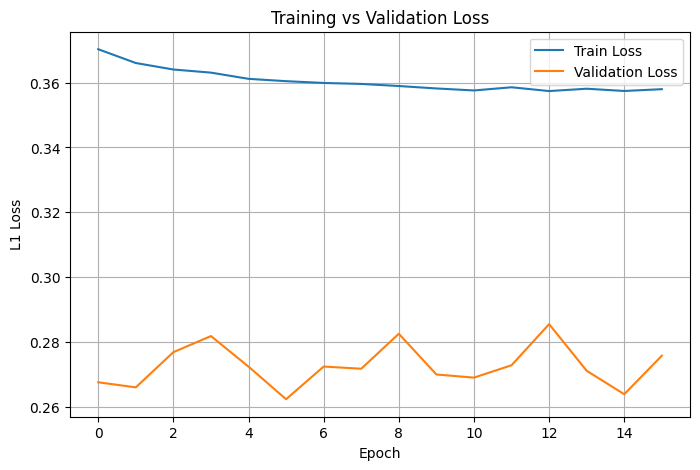

In [245]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

**Plot MAE**

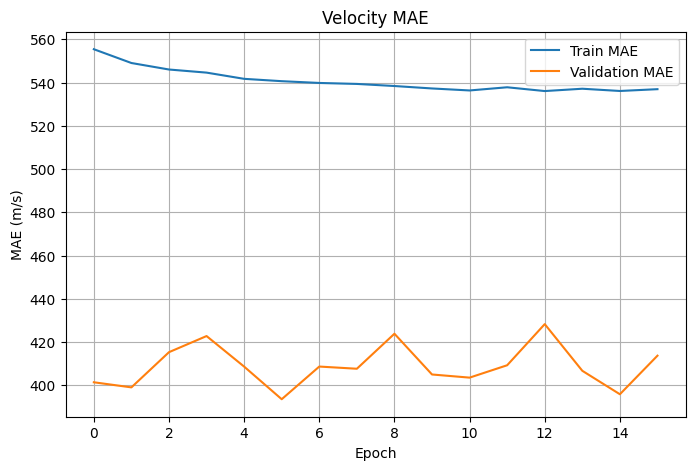

In [246]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_mae"],
    label="Train MAE"
)

plt.plot(
    history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (m/s)")
plt.title("Velocity MAE")
plt.legend()
plt.grid()

plt.show()

**LOAD BEST MODEL**

In [247]:
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

best_model = InversionNet(
    in_channels=checkpoint["in_channels"],
    out_hw=tuple(checkpoint["out_hw"])
)

best_model.load_state_dict(
    checkpoint["model_state"]
)

best_model = best_model.to(device)

best_model.eval()

print(
    "Loaded best model."
)

print(
    "Best validation MAE:",
    checkpoint["val_mae"]
)

Loaded best model.
Best validation MAE: 393.5991267089844


**VALIDATION PREDICTIONS**

In [248]:
def predict_validation_sample(
    dataset,
    index
):

    seis, target = dataset[index]

    input_tensor = (
        seis.unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        pred = best_model(
            input_tensor
        )

    pred = pred.squeeze().cpu().numpy()
    target = target.squeeze().numpy()

    pred = (
        (pred + 1.0)
        / 2.0
        * (VEL_MAX - VEL_MIN)
        + VEL_MIN
    )

    target = (
        (target + 1.0)
        / 2.0
        * (VEL_MAX - VEL_MIN)
        + VEL_MIN
    )

    return pred, target

**Visualize prediction**

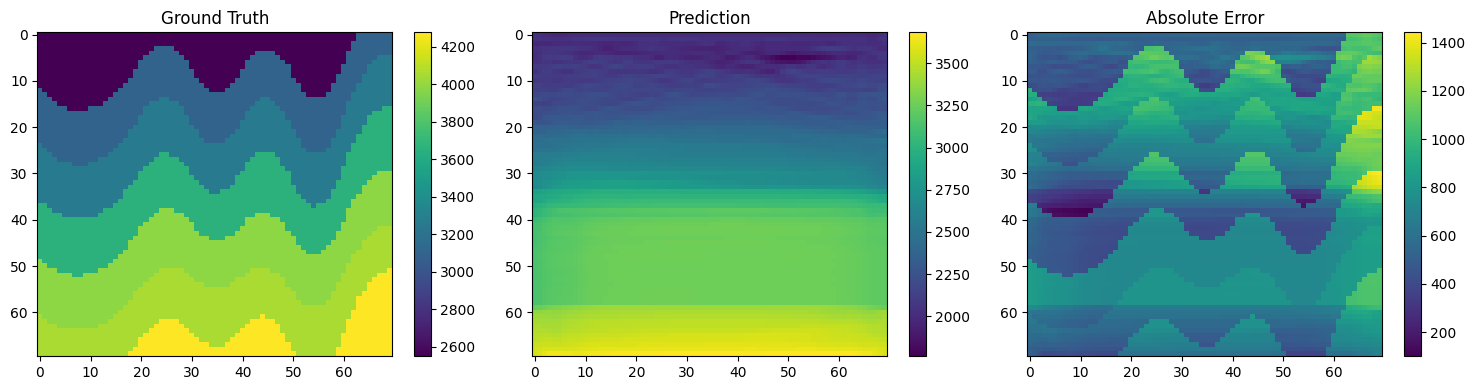

Sample MAE: 697.7564 m/s


In [249]:
pred, target = predict_validation_sample(
    val_ds,
    0
)

error = np.abs(
    pred - target
)

fig = plt.figure(
    figsize=(15, 4)
)

ax1 = fig.add_subplot(1, 3, 1)

im1 = ax1.imshow(
    target,
    aspect="auto"
)

ax1.set_title(
    "Ground Truth"
)

plt.colorbar(
    im1,
    ax=ax1
)

ax2 = fig.add_subplot(1, 3, 2)

im2 = ax2.imshow(
    pred,
    aspect="auto"
)

ax2.set_title(
    "Prediction"
)

plt.colorbar(
    im2,
    ax=ax2
)

ax3 = fig.add_subplot(1, 3, 3)

im3 = ax3.imshow(
    error,
    aspect="auto"
)

ax3.set_title(
    "Absolute Error"
)

plt.colorbar(
    im3,
    ax=ax3
)

plt.tight_layout()

plt.show()

print(
    "Sample MAE:",
    error.mean(),
    "m/s"
)

**TEST / SUBMISSION**

In [250]:
def load_x_columns(
    sample_submission_path
):

    with open(
        sample_submission_path,
        "r",
        newline=""
    ) as f:

        header = next(
            csv.reader(f)
        )

    x_cols = [
        c
        for c in header
        if c != "oid_ypos"
    ]

    x_indices = [
        int(
            re.match(
                r"x_(\d+)",
                c
            ).group(1)
        )
        for c in x_cols
    ]

    return x_cols, x_indices

In [251]:
x_cols, x_indices = load_x_columns(
    SAMPLE_SUBMISSION
)

print(
    "Number of x columns:",
    len(x_cols)
)

print(
    "First columns:",
    x_cols[:5]
)

print(
    "Last columns:",
    x_cols[-5:]
)

Number of x columns: 35
First columns: ['x_1', 'x_3', 'x_5', 'x_7', 'x_9']
Last columns: ['x_61', 'x_63', 'x_65', 'x_67', 'x_69']


In [252]:
test_files = sorted(
    glob.glob(
        os.path.join(
            TEST_DIR,
            "*.npy"
        )
    )
)

print(
    "Test files:",
    len(test_files)
)

print(
    "First test file:",
    test_files[0]
)

Test files: 65818
First test file: /kaggle/input/competitions/waveform-inversion/test/000039dca2.npy


In [253]:
test_path = test_files[0]

test_seis = np.asarray(
    np.load(test_path),
    dtype=np.float32
)

print(
    "Original test shape:",
    test_seis.shape
)

test_seis = (
    test_seis
    / seis_scale
)

test_tensor = torch.from_numpy(
    test_seis
).unsqueeze(0).to(device)

with torch.no_grad():

    prediction = best_model(
        test_tensor
    )

prediction = prediction.squeeze(
    0
).squeeze(
    0
).cpu().numpy()

prediction = (
    (prediction + 1.0)
    / 2.0
    * (VEL_MAX - VEL_MIN)
    + VEL_MIN
)

print(
    "Prediction shape:",
    prediction.shape
)

print(
    "Velocity range:",
    prediction.min(),
    prediction.max()
)

Original test shape: (5, 1000, 70)
Prediction shape: (70, 70)
Velocity range: 1693.5359 3677.0996


In [ ]:
# ============================================================
# FULL SUBMISSION GENERATION
# ============================================================
# The competition asks for every row (y) but only the ODD-valued
# x columns, per test file. Rather than guessing the exact
# "oid_ypos" string format, we drive everything off your actual
# sample_submission.csv so the output is guaranteed to line up.

import re
import pandas as pd
from torch.utils.data import Dataset, DataLoader

sample_sub = pd.read_csv(SAMPLE_SUBMISSION)

id_re = re.compile(r"^(?P<oid>.+)_y_(?P<y>\d+)$")
parsed = sample_sub["oid_ypos"].str.extract(id_re)
sample_sub["_oid"] = parsed["oid"]
sample_sub["_y"] = parsed["y"]

assert sample_sub["_oid"].notna().all(), (
    "Could not parse oid_ypos with pattern '{oid}_y_{y}'. "
    "Print sample_sub['oid_ypos'].head(10) and check the real format, "
    "then adjust id_re above."
)

sample_sub["_y"] = sample_sub["_y"].astype(int)

# Row positions in sample_sub for each oid, kept in submission order
oid_to_rows = sample_sub.groupby("_oid").indices

x_indices_arr = np.array(x_indices)  # column positions to keep (odd x, 0-indexed)

# Preallocate the output values array
values = np.zeros((len(sample_sub), len(x_cols)), dtype=np.float32)


class TestDataset(Dataset):
    def __init__(self, files, seis_scale):
        self.files = files
        self.seis_scale = seis_scale

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        seis = np.asarray(np.load(path), dtype=np.float32) / self.seis_scale
        oid = os.path.splitext(os.path.basename(path))[0]
        return torch.from_numpy(seis), oid


test_dataset = TestDataset(test_files, seis_scale)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

best_model.eval()

with torch.no_grad():
    for batch_seis, batch_oids in test_loader:

        batch_seis = batch_seis.to(device)
        preds = best_model(batch_seis)  # (B, 1, 70, 70)

        preds = preds.squeeze(1).cpu().numpy()
        preds = (preds + 1.0) / 2.0 * (VEL_MAX - VEL_MIN) + VEL_MIN

        for pred, oid in zip(preds, batch_oids):
            if oid not in oid_to_rows:
                continue

            rows = oid_to_rows[oid]
            ys = sample_sub["_y"].values[rows]
            values[rows] = pred[ys][:, x_indices_arr]

sample_sub[x_cols] = values

submission = sample_sub[["oid_ypos"] + x_cols]
submission.to_csv("submission.csv", index=False)

print("Wrote submission.csv with", len(submission), "rows.")
submission.head()
